# Ejercicios prácticos - Módulo 4

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

### 1. Para los siguientes modelos vistos en los temas anteriores realizá las siguientes pruebas:

#### a. `cs_nh`  una prueba predictiva a priori, todos los grupos juntos

Importo los datos utilizados y armo el diccionario de coordenadas:

In [ ]:
cs_data = pd.read_csv("chemical_shifts_theo_exp.csv")
diff = cs_data.theo - cs_data.exp
cat_encode = pd.Categorical(cs_data['aa'])
idx = cat_encode.codes
coords = {"aa": cat_encode.categories, "aa_flat":cat_encode.categories[idx]}

En el enunciado cuando se refiere a "todos los grupos juntos" quiere decir que no se utilicen los parámetros `dims` y `shape` a la hora de definir los priors. De este modo el modelo se define sin considerar la existencia de grupos entre los datos:

In [ ]:
with pm.Model() as cs_nh_grupos_juntos:
    mu = pm.Normal('mu', mu=0, sigma=1)
    sigma = pm.HalfNormal('sigma', sigma=2)

    y = pm.Normal('y', mu=mu, sigma=sigma, observed=diff)

    idata_cs_nh_juntos = pm.sample_prior_predictive(samples=100)

Notar que son los mismos priors usados en el módulo donde se definió el modelo pero obviando la existencia de grupos.

Ahora llevamos a capo la prueba predictiva *a priori*:

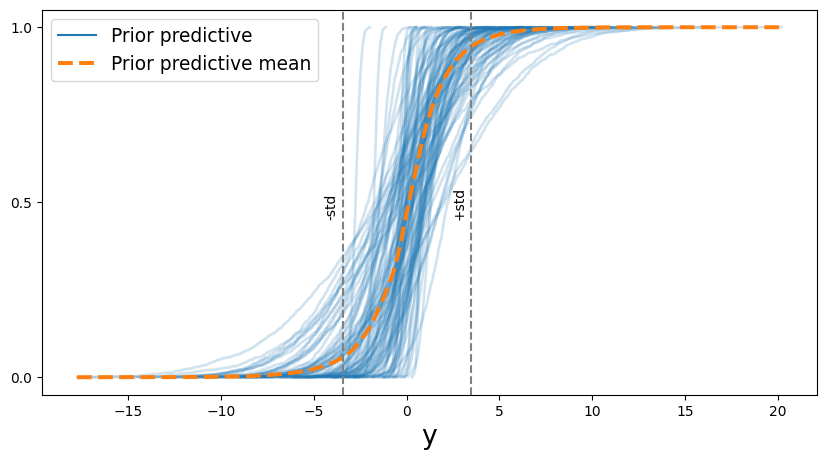

In [ ]:
ax = az.plot_ppc(idata_cs_nh_juntos, group="prior", kind="cumulative", figsize=(10, 5))

refs = {"+std":2*np.std(diff),
        "-std":-2*np.std(diff)}

for key, val in refs.items():
    ax.axvline(val, ls="--", color="0.5")
    ax.text(val-1, 0.5-(len(key)/100), key, rotation=90)

En este caso hice un gráfico similar al del módulo 4 para evaluar esta prueba predictiva *a priori*. Como guía para saber si los priors mapean los datos hacia valores razonables **utilicé la desviación estándar empírica presente en los datos observados**: las lineas verticales se encuentran a +2 y -2 desviaciones estándar del 0 (diferencia esperada).

Podemos ver entonces que los priors elegidos arrojan algunos resultados sin sentido pero están dentro de un rango razonable para nuestros datos. De este modo tenemos algo con sentido pero que a su vez muestra algo de ignorancia previa de cara a los datos que mirará durante la estimación.

#### b. `cs_nh`  una prueba predictiva a posteriori, todos los grupos juntos

En este caso utilizamos el modelo que definimos en el inciso anterior:

In [ ]:
with cs_nh_grupos_juntos:
    idata_cs_nh_juntos_posterior = pm.sample(progressbar=False)
    idata_cs_nh_juntos_posterior.extend(pm.sample_posterior_predictive(idata_cs_nh_juntos_posterior, progressbar=False))

Con el sampleo listo ahora observamos el gráfico de la prueba predictiva *a posteriori*:

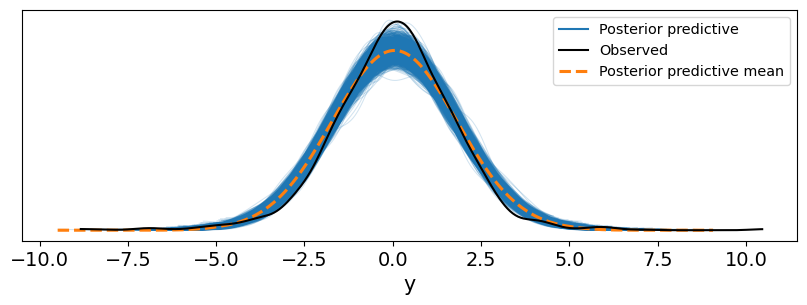

In [ ]:
ax = az.plot_ppc(idata_cs_nh_juntos_posterior, figsize=(10, 5))

De este gráfico podemos ver que la distribución *a posteriori* subestima los valores en torno al cero (linea naranja debajo de linea negra) y para valores mayores a 2.5 (o menores a -2.5) se sobreestima levemente la diferencia. **Sin embargo es un modelo dentro de todo aceptable**.

#### c. `cs_nh` una prueba predictiva a posteriori, los 19 grupos por separado

En este caso el modelo es similar al `cs_nh` que se definió en el módulo 3:

In [ ]:
with pm.Model(coords=coords) as cs_nh_grupos_separados:
    mu = pm.Normal('mu', mu=0, sigma=1, dims="aa")
    sigma = pm.HalfNormal('sigma', sigma=2, dims="aa")
    y = pm.Normal('y', mu=mu[idx], sigma=sigma[idx], observed=diff, dims="aa_flat")

    idata_cs_nh_separados = pm.sample(progressbar=False)
    idata_cs_nh_separados.extend(pm.sample_posterior_predictive(idata_cs_nh_separados, progressbar=False))

Armo el gráfico:

/tmp/ipython-input-2935674538.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


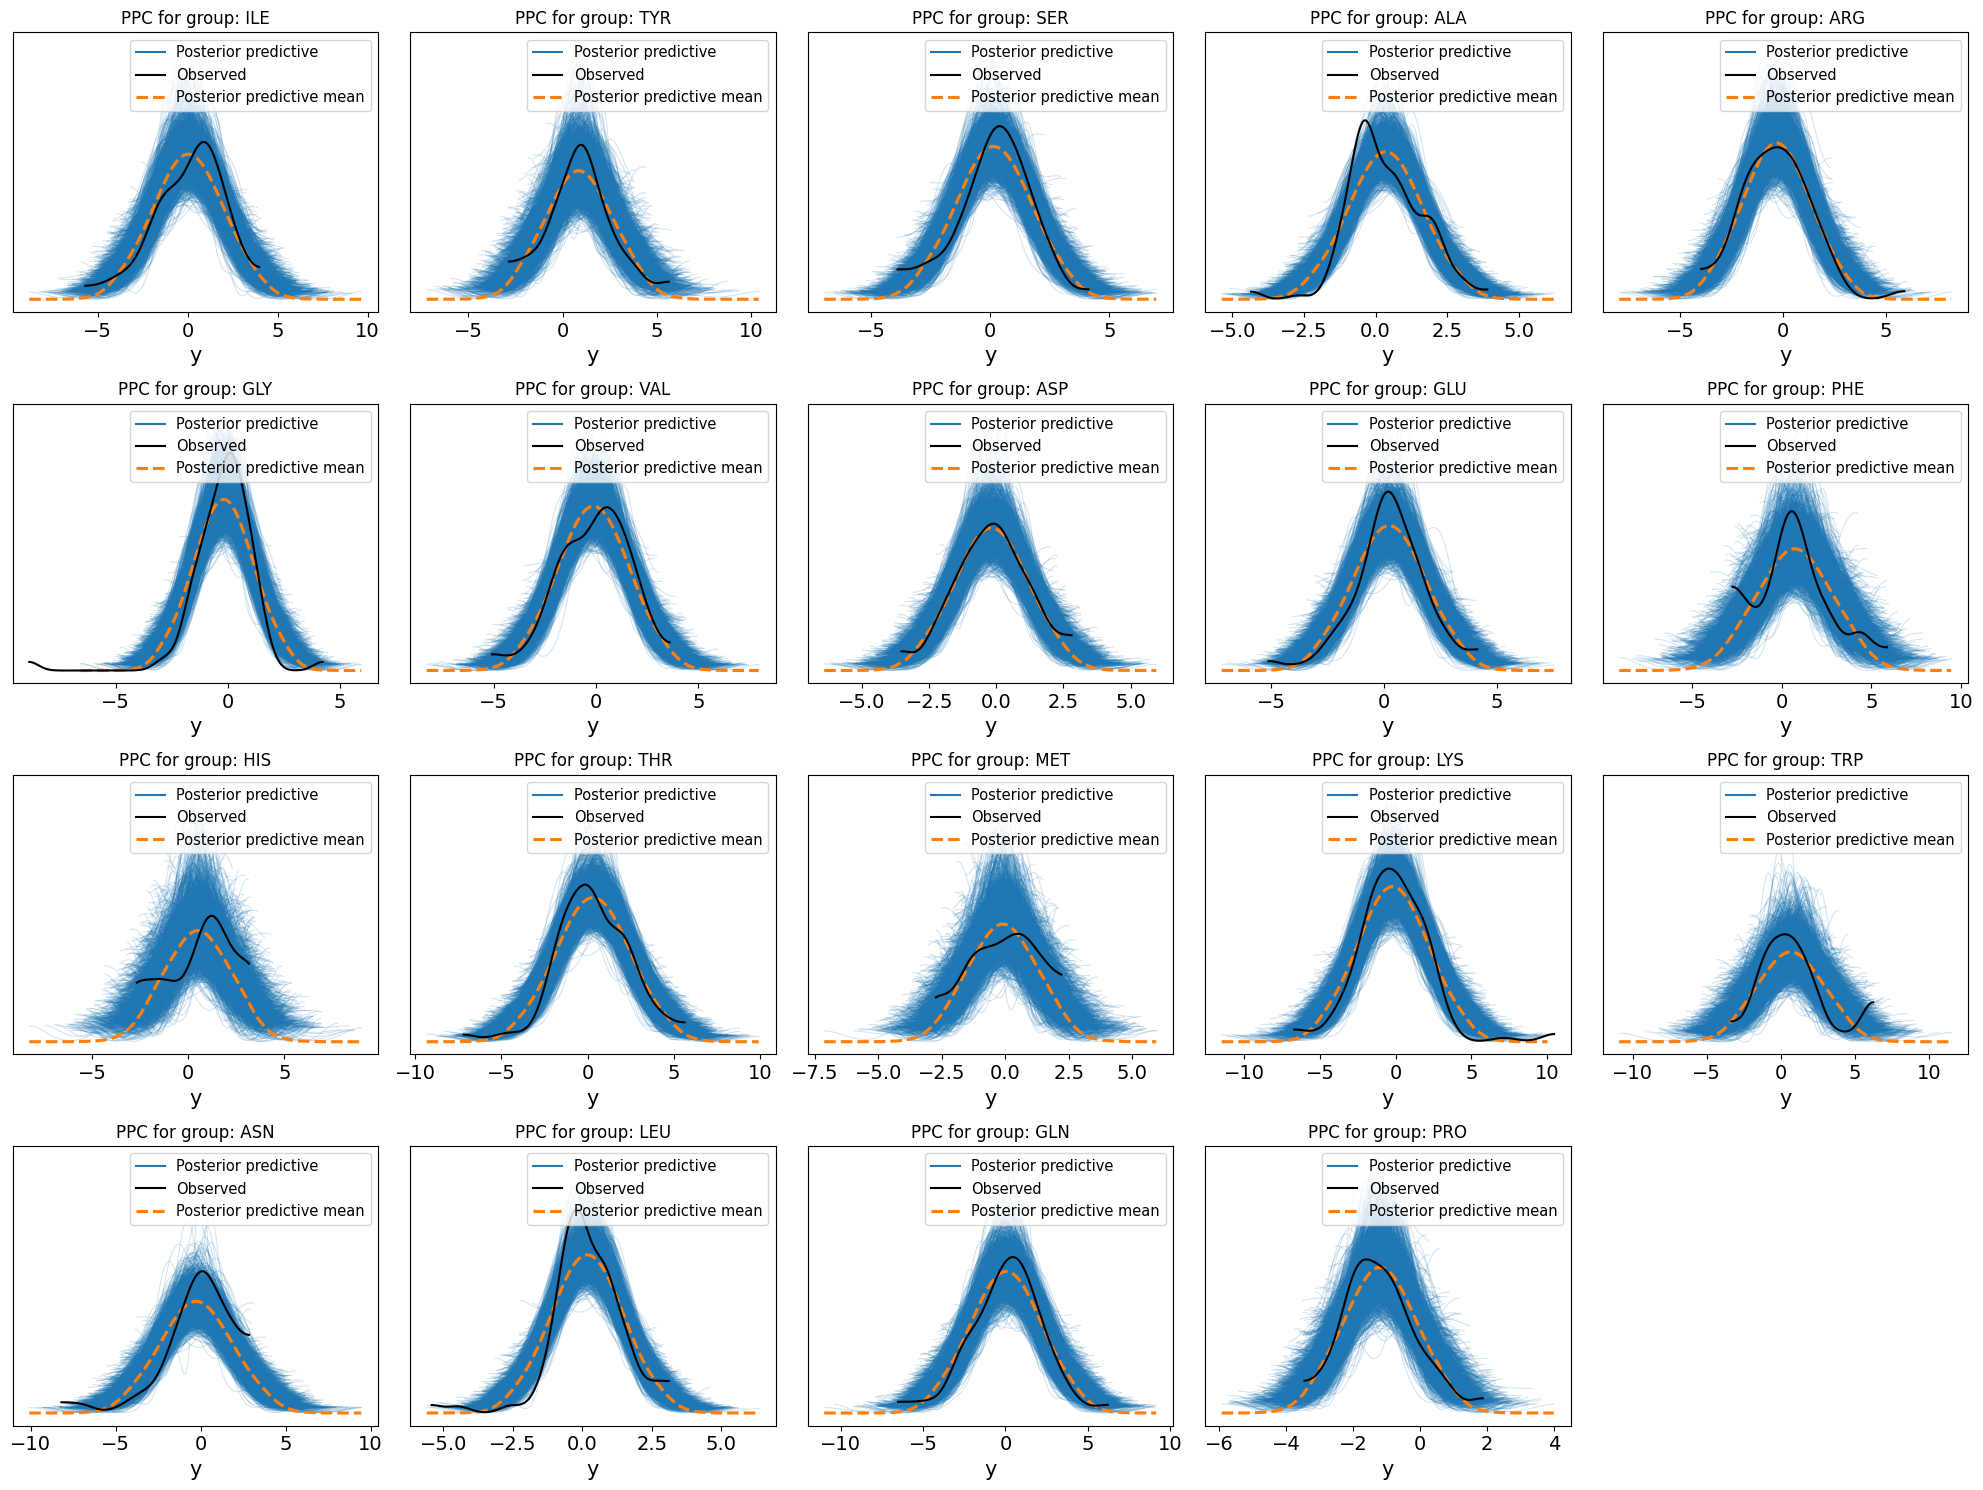

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 15))
axes = axes.flatten()

for i, group in enumerate(coords['aa_flat'].unique()):
    az.plot_ppc(idata_cs_nh_separados, coords={"aa_flat": [group]}, ax=axes[i])
    axes[i].set_title(f'PPC for group: {group}')

# Escondo los subplots que no se utilizaron
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Este gráfico separado por cada grupo presente en los datos permite ver a más detalle en donde se queda corto el modelo y en donde triunfa. Hay casos de grupos de aminoácidos como **ASP** en donde la posterior coincide casi completamente con la distribución observada, y otros casos como el de **HIS** en donde se nota la diferencia entre la posterior y la distribución observada.

Sin embargo podemos ver que resulta ser un buen modelo para estos datos ya que en la mayoría de los casos la distribución *a posteriori* toma una forma dentro de todo similar a la que toman las distribuciones de cada grupo.

### 2. Usando un modelo construido para tus propios datos realizá una prueba predictiva a priori y en función del resultado modificá los priors elegidos.

En este caso se me ocurre simular datos provenientes de una distribución normal de la siguiente forma:

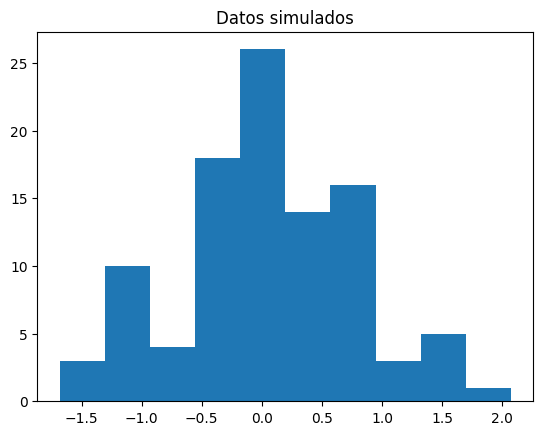

In [ ]:
datos_sim = np.random.normal(0, 0.7, 100)
plt.hist(datos_sim)
plt.title("Datos simulados")
plt.show()

Supongamos que estamos modelando una variable que toma valores pequeños y queremos estimar la media de la misma.

Como no sabemos casi nada podemos decir entonces, como primera aproximación que los priors que queremos utilizar son normales y bastante vagos:

In [ ]:
with pm.Model() as modelo_prior_malo:
  prior_malo = pm.Normal("prior_malo", 0, 10)
  y = pm.Normal("y",mu = prior_malo, sigma= 10, observed=datos_sim)
  idata_modelo_prior_malo = pm.sample_prior_predictive(samples=100)

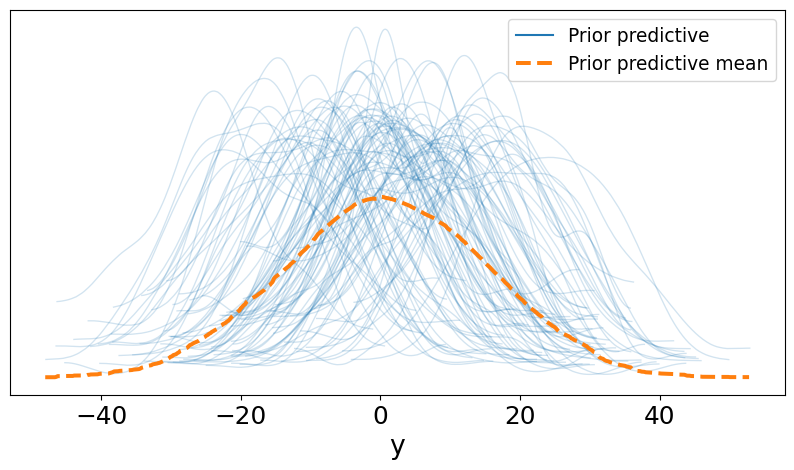

In [ ]:
ax = az.plot_ppc(idata_modelo_prior_malo, group="prior", figsize=(10, 5))
plt.show()

Podemos ver que se logra extender hasta el +-40 y los valores que nos interesan son más pequeños, por lo tanto decimos que este prior no nos sirve y decidimos bajar la varianza para tener valores más razonables:

In [ ]:
with pm.Model() as modelo_prior_bueno:
  prior_bueno = pm.Normal("prior_bueno", 0, 1)
  y = pm.Normal("y",mu = prior_bueno, sigma= 1, observed=datos_sim)
  idata_modelo_prior_bueno = pm.sample_prior_predictive(samples=100)

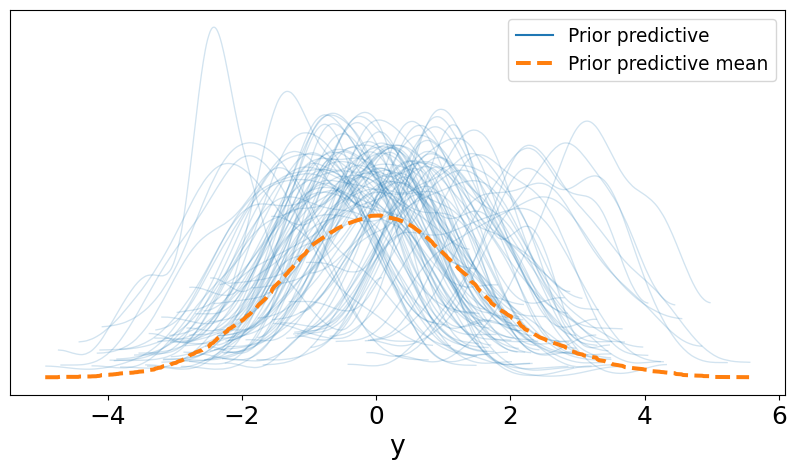

In [ ]:
ax = az.plot_ppc(idata_modelo_prior_bueno, group="prior", figsize=(10, 5))
plt.show()

Vemos que este aún toma valores extremos como el -4 y el 6 pero por lo menos ya está más centrado en los valores que si observamos (del -2 al 2), por lo tanto logramos corregir los priors y hacer que durante la estimación se exploren regiones más razonables entre los datos.

### 3. Usando la función `az.plot_bpv` y sobre la distribución a posteriori del modelo `cs_nh` realizá:

#### a. Un gráfico de los p-valores marginales, para todos los grupos juntos.

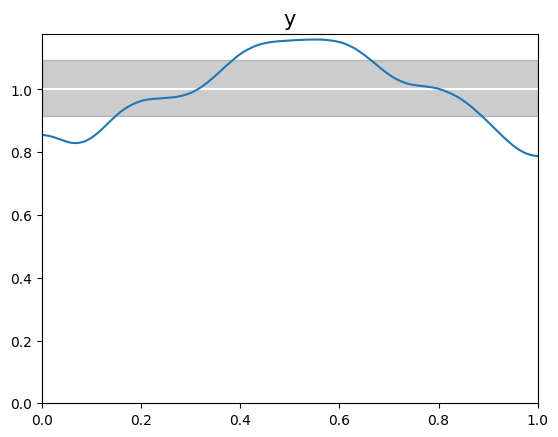

In [ ]:
az.plot_bpv(idata_cs_nh_juntos_posterior)
plt.show()

En este caso podemos ver los p-valores marginales para la versión del modelo `cs_nh` con los grupos juntos. Hay que recordar que los valores de $x$ se pueden interpretar como cuantiles y eso lo que nos indica es que para valores extremos de la distribución esta versión del modelo no se ajusta bien, incluso en valores en torno a la mediana la distribución del modelo tampoco se ajusta bien.

Esto podría estar relacionado con lo que vimos en la construcción de esta versión del modelo en donde se subestimaba a los valores centrales de la distribución observada y se sobreestimaba a los valores mayores a 2.5 (o menores a -2.5) que son justamente los extremos.

#### b. Un gráfico de los p-valores marginales, para los 19 grupos por separado.

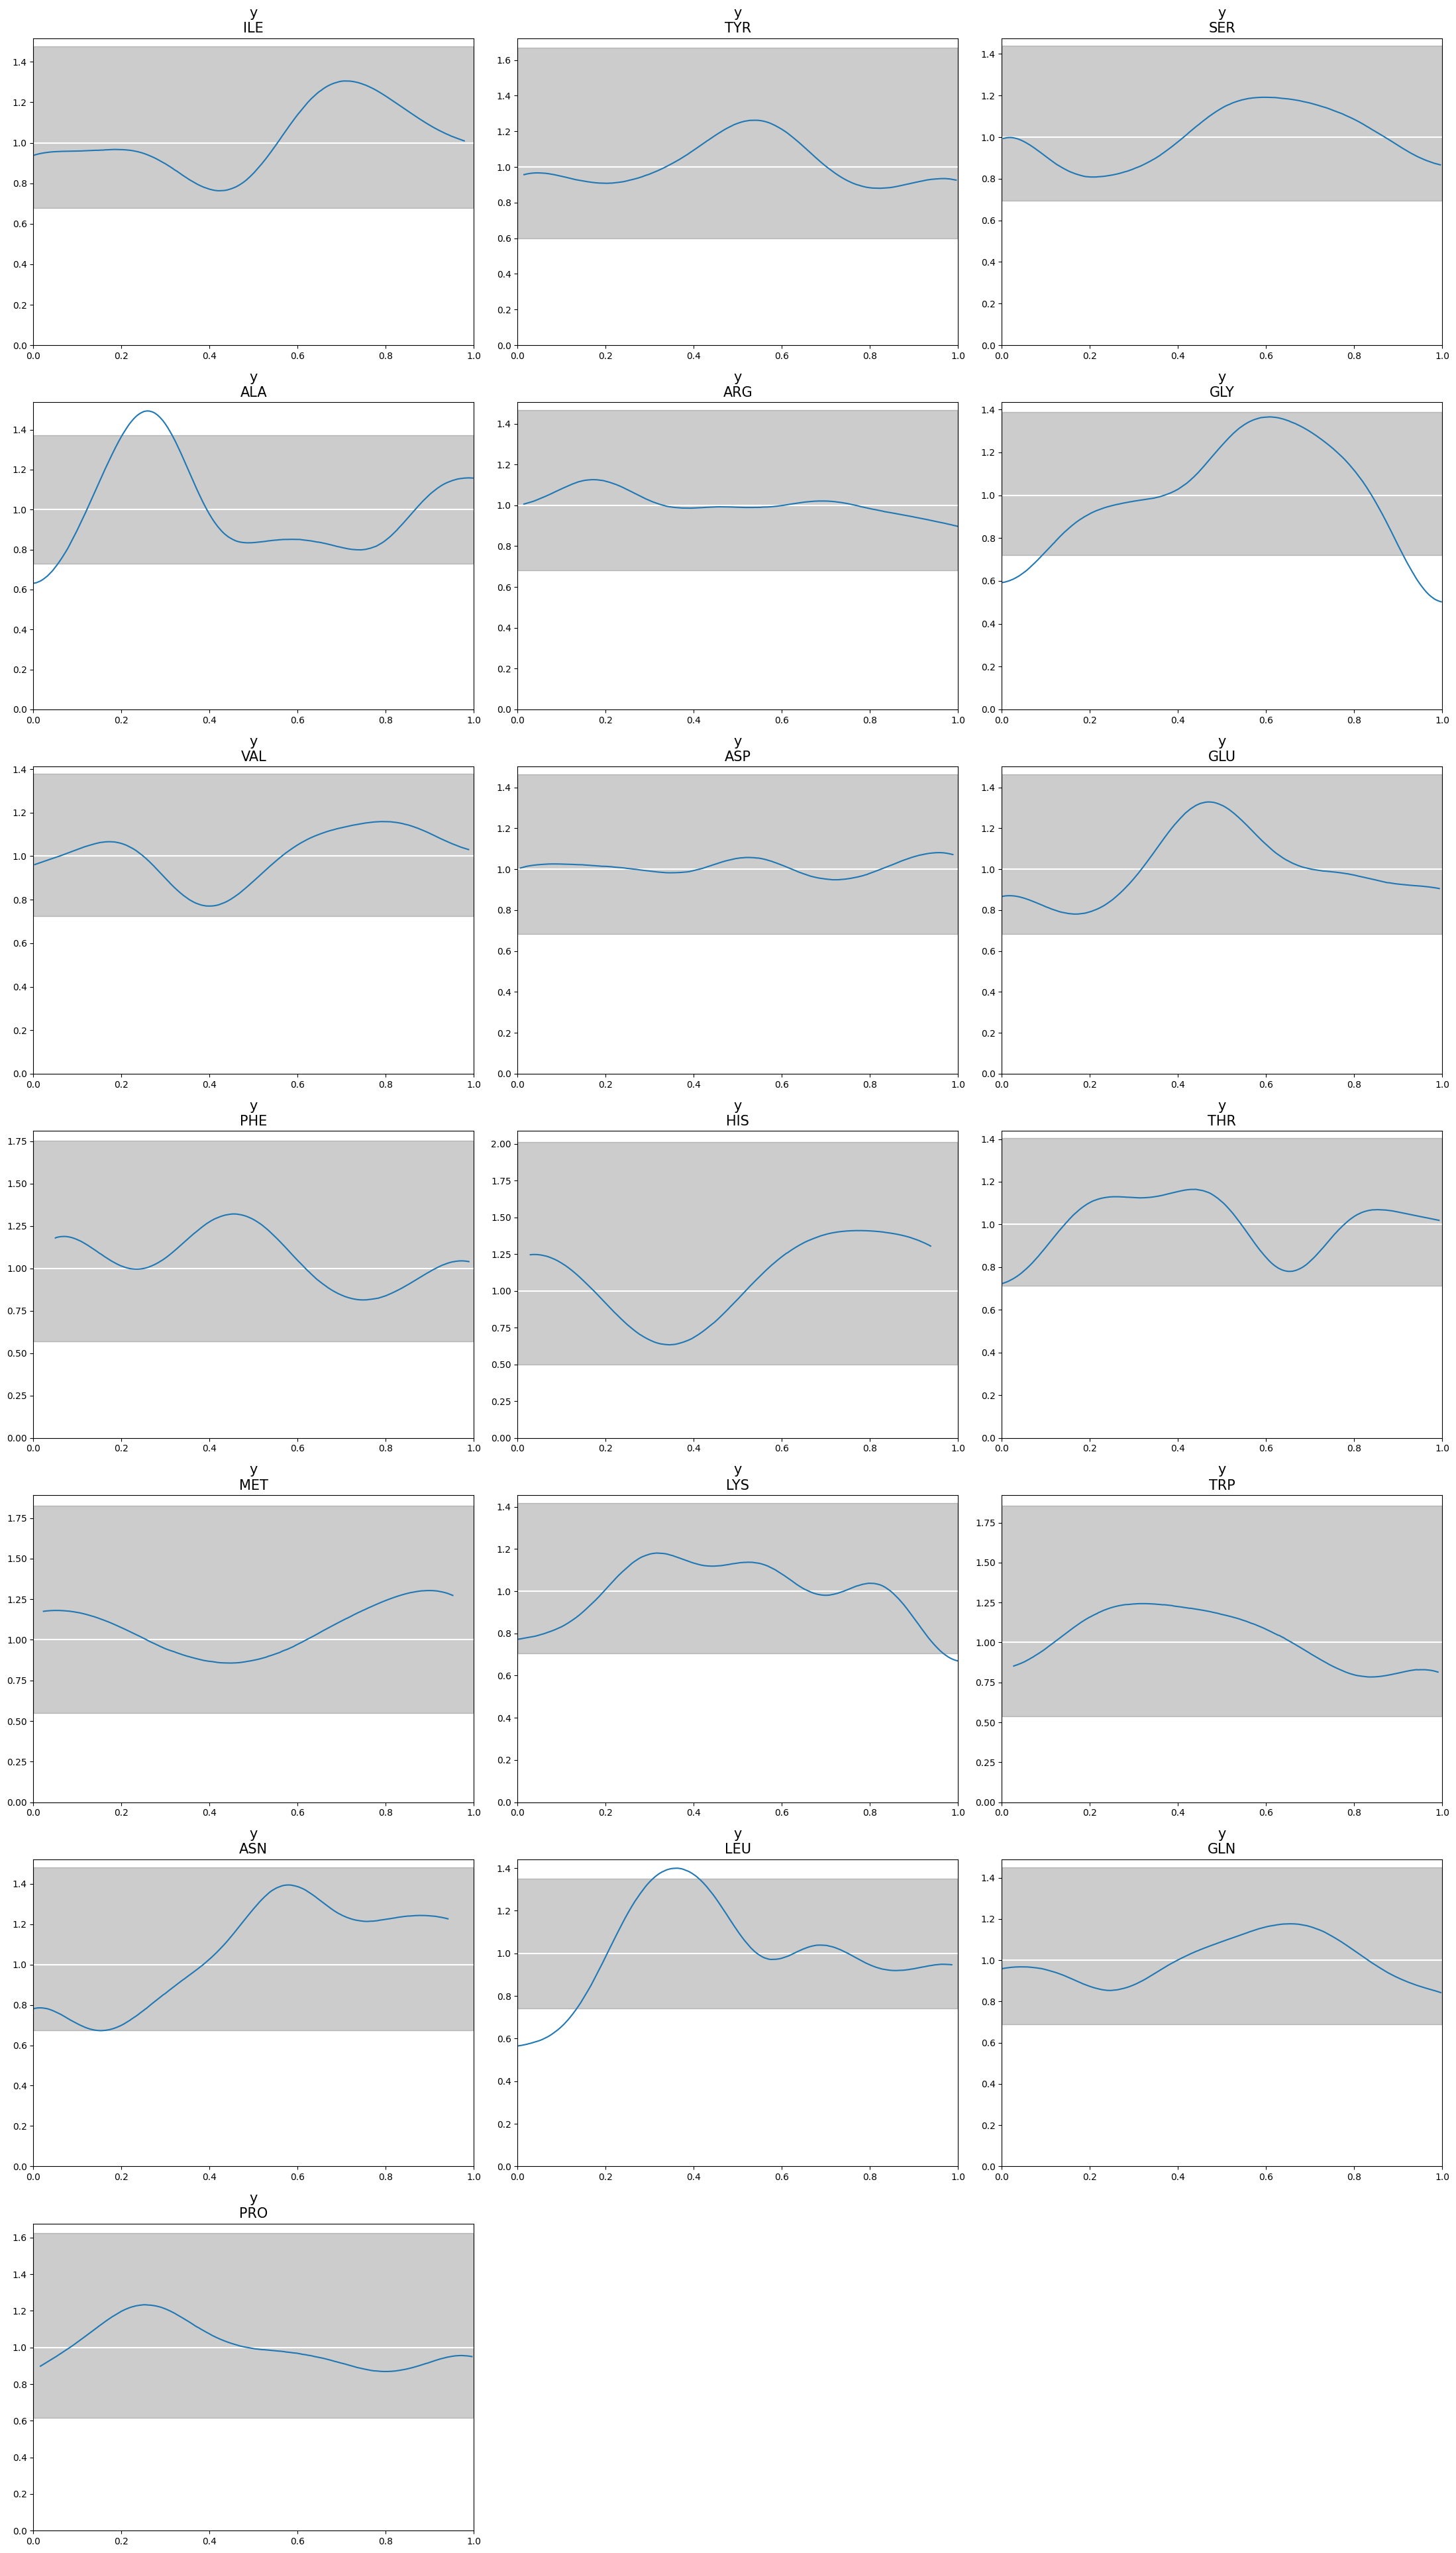

In [ ]:
az.plot_bpv(idata_cs_nh_separados,
            coords={"aa_flat": [cat_encode.categories]},
            flatten=[],
            grid = (7,3))
plt.tight_layout()
plt.show()

De este gráfico con los p-valores marginales para la versión del modelo `cs_nh` con los grupos separados podemos ver que en casi todos los casos los datos se ubicaron dentro de la zona "permitida" (recuadro gris), por lo tanto podemos ver que en lineas generales tuvo un mejor desempeño que su contraparte con los grupos juntos.

#### c. Un gráfico de los p-valores para un estadístico a su elección que no sea la media, para los 19 grupos por separado.

Para este caso decidí elegir la desviación estándar como estadístico a evaluar:

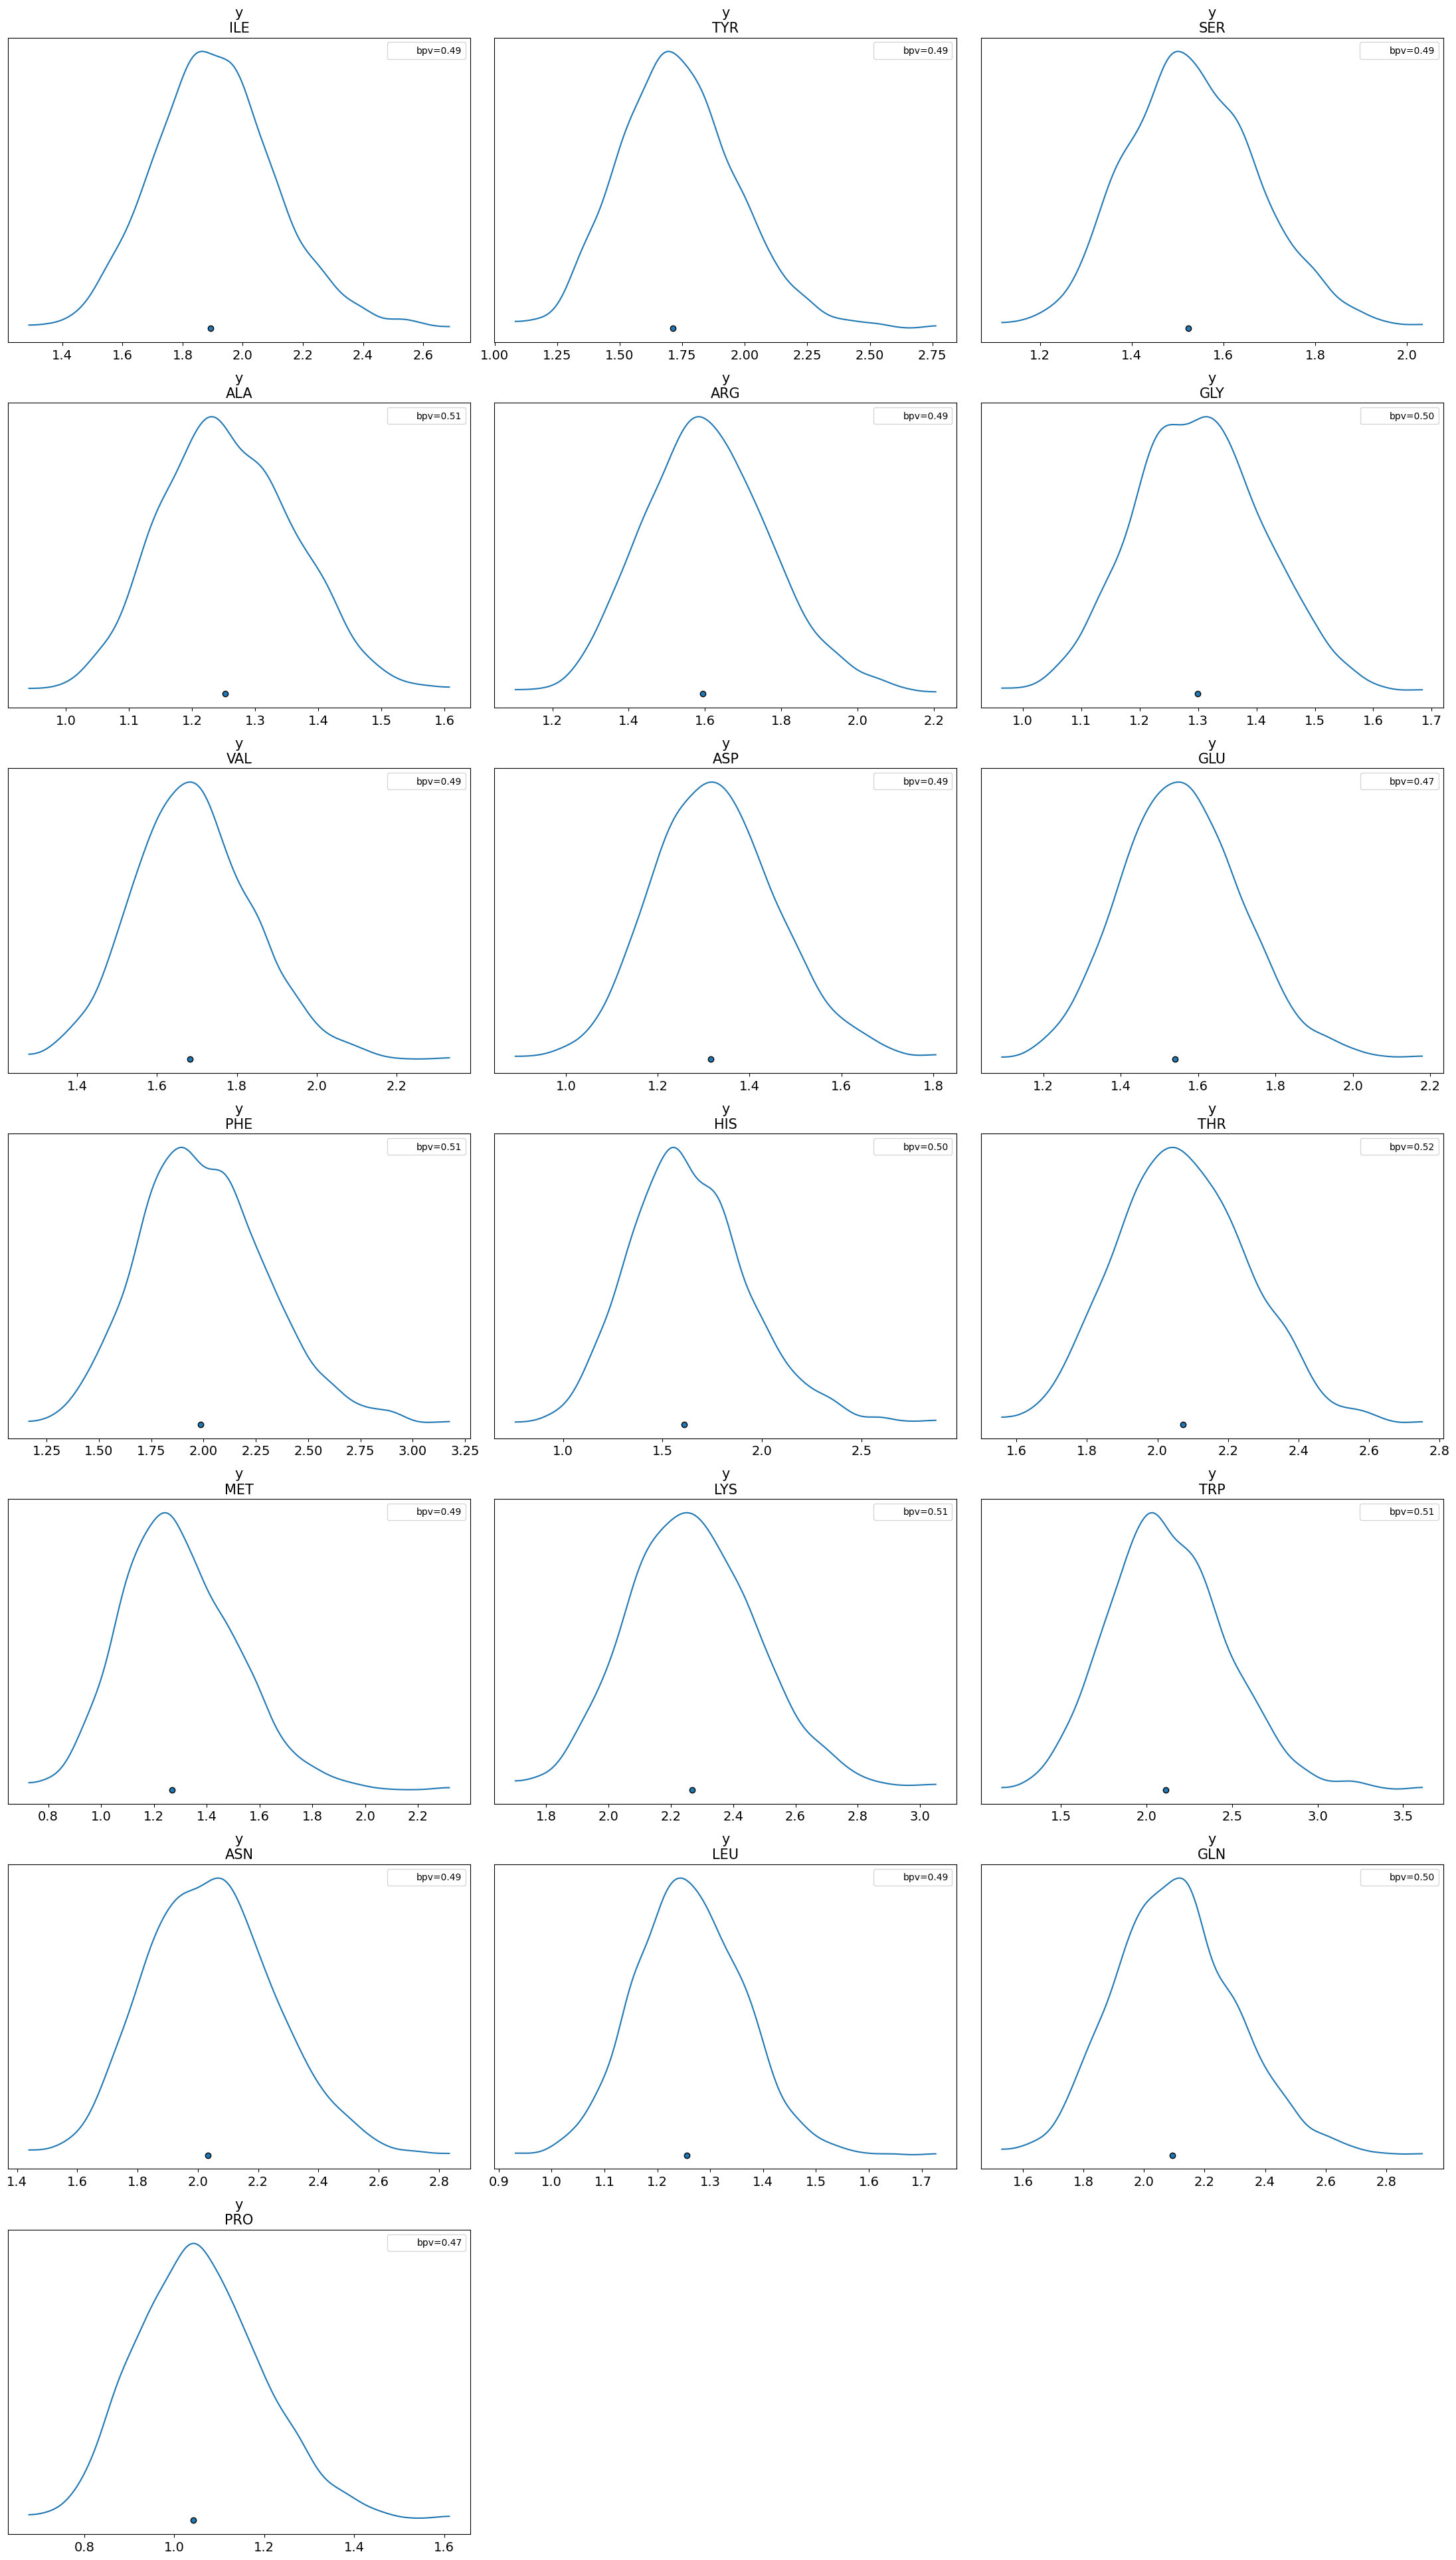

In [ ]:
az.plot_bpv(idata_cs_nh_separados,
            kind= 't_stat',
            t_stat = "std",
            coords={"aa_flat": [cat_encode.categories]},
            flatten=[],
            grid = (7,3))
plt.tight_layout()
plt.show()

Para tener una idea de lo que estamos viendo en estos gráficos hay que recordar que si los valores observados coinciden con los predichos, **el valor esperado será 0,5**. Es decir, la mitad de las predicciones estarán por debajo de las observaciones y la otra mitad por encima.

Aquí vemos que en la mayoría de los graficos el p-valor bayesiano que obtenemos gira en torno al 0.5 y eso indica entonces que los datos estimados coinciden con los observados. **Por lo tanto podemos concluir que en términos de la desviación estándar el modelo con los grupos separados se desempeñó bien**.

### 4. Para ganar intuición sobre los gráficos de p-valores marginales. Vamos a hacer el siguiente experimento. Vamos a crear 4 InferenceData, todos con el mismo grupo “observed_data” y con 200 observaciones (extra, podés probar cambiar el número de observaciones).

* Uno de ellos con predicciones que provengan de una distribución más ancha que la observada
* Otro con una predicciones que provengan de una distribución más angosta
* El tercero con la media desplazada respecto de la observada
* El cuarto con muestra de la misma distribución que la observada.

Exlicá las observaciones.

Primero empiezo por generar los datos, en este caso la distribución que se me ocurre es una Normal estándar:

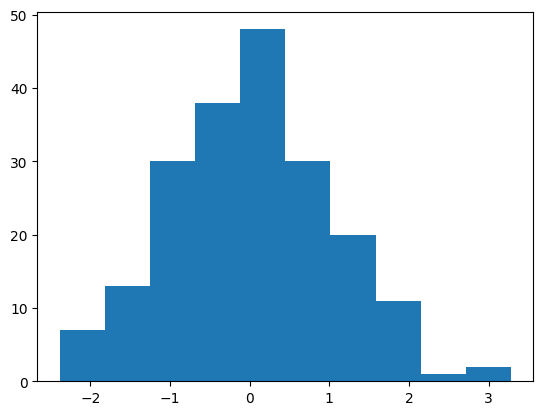

In [ ]:
observaciones = np.random.normal(0, 1, 200)
plt.hist(observaciones)
plt.show()

**Ahora armo el primer InferenceData, que contenga predicciones que provengan de una distribución más ancha que la observada:**

In [ ]:
with pm.Model() as mas_ancha_que_observada:
    mu = pm.Normal("mu", mu = 0, sigma = 5)
    y = pm.Normal("y",mu = mu, sigma = 5, observed = observaciones)

    idata_mas_ancha = pm.sample(progressbar= False)
    idata_mas_ancha.extend(pm.sample_posterior_predictive(idata_mas_ancha, progressbar= False))

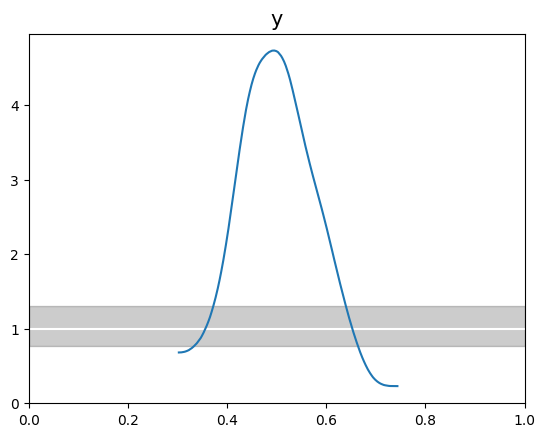

In [ ]:
az.plot_bpv(idata_mas_ancha)
plt.show()

Hay que considerar que los p-valores marginales bayesianos se rigen por la siguiente expresión:

$$p(\tilde{y_i} < y_{obs_i} | y)$$

Y lo que vemos en el gráfico es la densidad de este p-valor marginal bayesiano. Podemos ver que en torno al centro (cuartil 0.5 en el eje $x$) la densidad se sale del recuadro gris y toma mucha densidad, eso es porque hay mucha probabilidad de que el valor simulado sea menor que el observado ya que está proviniendo de una distribución más ancha que no está tan concentrada en el centro justamente.

Luego en en cuartiles más extremos vemos que la densidad se reduce y está por debajo del recuadro gris, eso es porque como nuestros datos observados si están concentrados en el centro no tienen tanta probabilidad de aparecer en estos lugares mientras que la distribución con la cual se simuló si tiene probabilidad de generar datos ahí.

**Va el InferenceData, que contenga predicciones que provengan de una distribución más angosta que la observada:**

In [ ]:
with pm.Model() as mas_angosta_que_observada:
    mu = pm.Normal("mu", mu = 0, sigma = 0.1)
    y = pm.Normal("y",mu = mu, sigma = 0.1, observed = observaciones)

    idata_mas_angosta = pm.sample(progressbar= False)
    idata_mas_angosta.extend(pm.sample_posterior_predictive(idata_mas_angosta, progressbar= False))

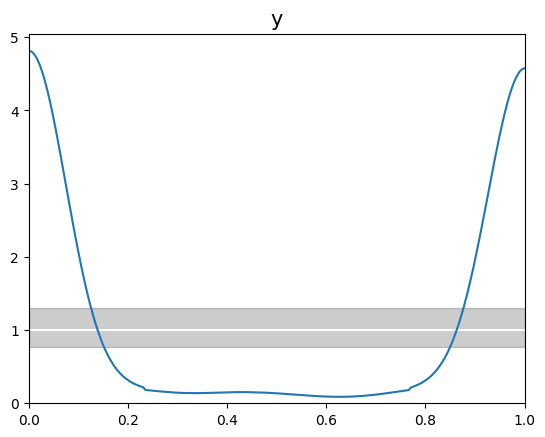

In [ ]:
az.plot_bpv(idata_mas_angosta)
plt.show()

De este no hay mucho que decir ya que es el caso opuesto al anterior: hay pocas chances de que un dato simulado sea menor que uno observado en torno al centro y muchas chances de que un dato observado sea mayor que uno simulado en los extremos.

**Va el InferenceData, que contenga predicciones que provengan de una distribución con la media desplazada respecto de la observada:**

In [ ]:
with pm.Model() as mas_desplazada_que_observada:
    mu = pm.Normal("mu", mu = 5, sigma = 0.1)
    y = pm.Normal("y",mu = mu, sigma = 1, observed = observaciones)

    idata_mas_desplazada = pm.sample(progressbar= False)
    idata_mas_desplazada.extend(pm.sample_posterior_predictive(idata_mas_desplazada, progressbar= False))

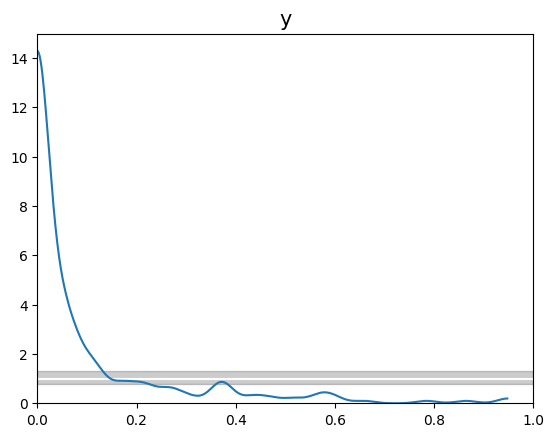

In [ ]:
az.plot_bpv(idata_mas_desplazada)
plt.show()

Aquí lo que vemos es que como las distribuciones observadas y simuladas no coinciden la densidad del p-valor marginal toma valores muy altos en regiones donde si hay datos de los observados y valores muy bajos en la región donde viven los datos simulados.

**Por último el InferenceData, que contenga predicciones que provengan de una distribución similar a la observada:**

In [ ]:
with pm.Model() as similar_a_observada:
    mu = pm.Normal("mu", mu = 0, sigma = 1)
    y = pm.Normal("y",mu = 0, sigma = 1, observed = observaciones)

    idata_similar = pm.sample(progressbar= False)
    idata_similar.extend(pm.sample_posterior_predictive(idata_similar, progressbar= False))

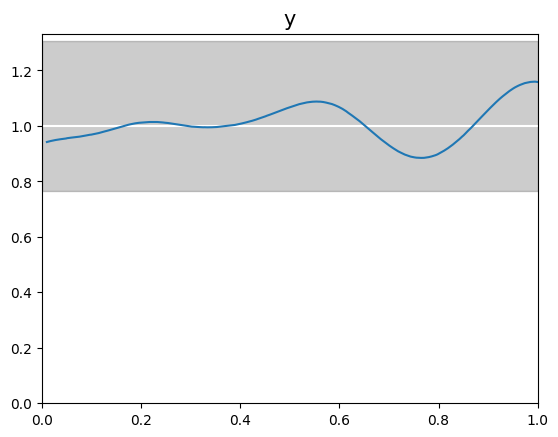

In [ ]:
az.plot_bpv(idata_similar)
plt.show()

Este sería el caso ideal, el del "todo bien". Vemos que la densidad no sale del recuadro gris y que tiende a ser una uniforme que asigna densidad 1 a lo largo de todos los cuartiles de la distribución.

### 5. (extra) Usando la transformada integral de probabilidad escribí un algoritmo que utilizando una distribución uniforme permita generar muestras aleatorias de cualquier distribución de probabiliad.

Primero tomemos en cuenta lo que nos dice la propiedad transformada integral de probabilidad (PIT):

*Dada una variable aleatoria continua $X$ y su CDF $F_X$ podemos computar una variable aleatoria con distribución uniforme estándar haciendo:*

$$Y = F_X(X)$$

*Es decir si tomamos una variable aleatoria $X$ y le aplicamos su propia CDF, la transformamos en $Y \sim U[0, 1]$*

Entonces para generar muestras aleatorias de cualquier distribución de probabilidad hay que seguir el paso inverso el cual sería:

$$X = F_X^{-1}(Y)$$

En donde $F_X^{-1}$ representa la inversa de la función de distribución acumulada para la distribución que nos interesa samplear. En este caso para resolverlo me voy a apoyar de las distribuciones presentes en [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html), las cuales tienen todas implementadas el método [`.ppf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.ppf.html#scipy.stats.rv_continuous.ppf) que representa a la función inversa de la CDF.

In [19]:
def generar_samples_para_distribucion(distribucion: stats.rv_continuous | stats.rv_discrete, n_samples: int) -> np.ndarray:
    u = np.random.uniform(size=n_samples)
    return distribucion.ppf(u)

Bueno eso fue muy sencillo, ahora comprobemos que funciona con un par de distribuciones conocidas:

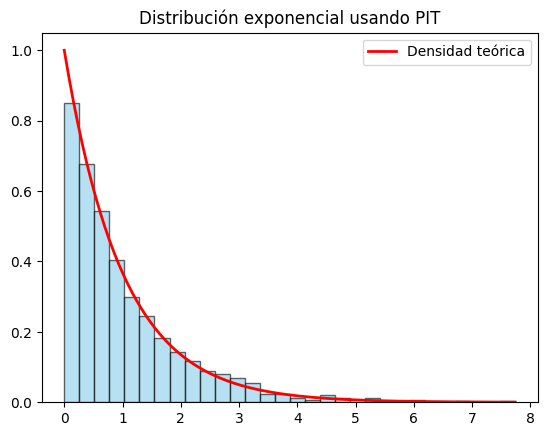

In [18]:
samples = generar_samples_para_distribucion(stats.expon(), 1000)
plt.hist(samples, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor = 'black')
x = np.linspace(0, max(samples), 200)
plt.plot(x, stats.expon().pdf(x), 'r-', lw=2, label='Densidad teórica')
plt.title("Distribución exponencial usando PIT")
plt.legend()
plt.show()

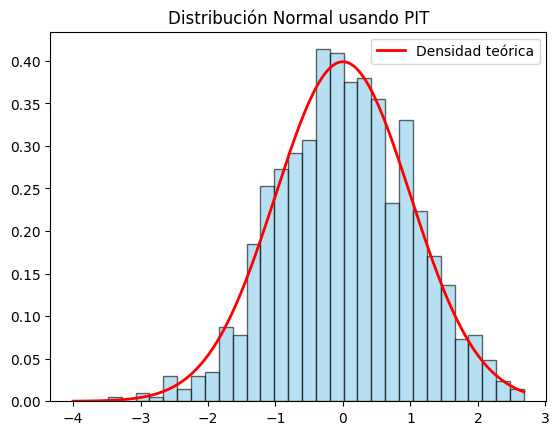

In [17]:
samples = generar_samples_para_distribucion(stats.norm(), 1000)
plt.hist(samples, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor = 'black')
x = np.linspace(-4, max(samples), 200)
plt.plot(x, stats.norm().pdf(x), 'r-', lw=2, label='Densidad teórica')
plt.title("Distribución Normal usando PIT")
plt.legend()
plt.show()

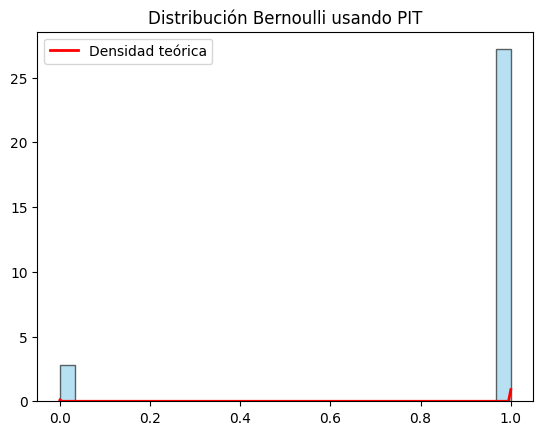

In [25]:
samples = generar_samples_para_distribucion(stats.bernoulli(0.9), 1000)
plt.hist(samples, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor = 'black')
x = np.linspace(0, max(samples), 200)
plt.plot(x, stats.bernoulli(0.9).pmf(x), 'r-', lw=2, label='Densidad teórica')
plt.title("Distribución Bernoulli usando PIT")
plt.legend()
plt.show()